# CNN (YOLO)

OBJECT DETECTIOn

In [11]:
!pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable


In [12]:
from ultralytics import YOLO

# Load the latest 2026 pre-trained model (e.g., YOLO26 small version)
model = YOLO("yolo26s.pt") 

# Run detection on video/camera stream
# classes=[0, 1, 2, 3, 5, 7] filters for person, bicycle, car, motorcycle, bus, and truck
results = model.track(
    source="test/img",
    save=True,
    project="tracked Result",        
    name="tracked_images",
    tracker="bytetrack.yaml",
    save_txt=True,
    save_conf=True,
    classes=[0, 1, 2, 3, 5, 7]
)






WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2000 c:\Users\abdul\OneDrive\Desktop\Dl project\test\img\ac517380-00000000.jpg: 384x640 8 cars, 11.4ms
image 2/2000 c:\Users\abdul\OneDrive\Desktop\Dl project\test\img\ac56c836-bdabca21.jpg: 384x640 6 persons, 1 bicycle, 8 cars, 2 buss, 10.5ms
image 3/2000 c:\Users\abdul\OneDrive\Desktop\Dl project\test\img\ac6d4f42-00000000.jpg: 384x640 9 cars, 1 truck, 28.0ms
image 4/2000 c:\Users\abdul\OneDrive\Desktop\Dl project\test\img\ac6e638d-7c84846d.jpg: 3

In [13]:
import cv2
import pandas as pd

# 1. Load your YOLOv26s/v8s model (e.g., trained on BDD100K)
model = YOLO('yolo26s.pt') 

def generate_traffic_csv(video_path, output_csv='traffic_log.csv'):
    cap = cv2.VideoCapture(video_path)
    data_log = []
    frame_count = 0

    while cap.isOpened():
        success, frame = cap.read()
        if not success: break
        
        # 2. Inference: Detect cars, buses, trucks, and motorcycles
        results = model(frame, classes=[2, 3, 5, 7], verbose=False)
        vehicle_count = len(results[0].boxes)
        
        # Log counts every 30 frames (approx. every 1 second)
        if frame_count % 30 == 0:
            data_log.append({'timestamp': frame_count // 30, 'count': vehicle_count})
        
        frame_count += 1

    cap.release()
    df = pd.DataFrame(data_log)
    df.to_csv(output_csv, index=False)
    print(f"Traffic log saved to {output_csv}")

generate_traffic_csv('traffic_video.mov')

Traffic log saved to traffic_log.csv


In [14]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load PeMS08 Data
def load_pems_data(file_path):
    # Ensure the path is correct for your local environment
    data = np.load(file_path)['data'] 
    flow_data = data[:, 0, 0].reshape(-1, 1) # Feature 0 is usually flow
    return flow_data

# 2. Create Sequences
def create_sequences(data, seq_length=12):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# 3. Define LSTM Architecture
class TrafficLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# --- Training and Saving ---
# Load and scale data
raw_data = load_pems_data('PEMS08.npz/PEMS08.npz') 
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(raw_data)

X, y = create_sequences(scaled_data)
X_train = torch.from_numpy(X).float()
y_train = torch.from_numpy(y).float()

# Initialize Model
model_lstm = TrafficLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# Training Loop
losses = []
for epoch in range(50):
    model_lstm.train()
    optimizer.zero_grad()
    outputs = model_lstm(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 10 == 0: print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# CORRECTION: Save Trained Weights
torch.save(model_lstm.state_dict(), 'traffic_lstm_weights.pt')
print("LSTM Weights Saved Successfully!")



Epoch 0, Loss: 0.2073
Epoch 10, Loss: 0.0536
Epoch 20, Loss: 0.0446
Epoch 30, Loss: 0.0411
Epoch 40, Loss: 0.0320
LSTM Weights Saved Successfully!


In [15]:
# --- Evaluation & Congestion Check ---
def evaluate_and_check_congestion(yolo_logs_path):
    # 1. Load YOLO Detections
    yolo_df = pd.read_csv(yolo_logs_path)
    actual_counts = yolo_df['count'].values
    
    # 2. Load Trained Weights for Prediction
    model_lstm.load_state_dict(torch.load('traffic_lstm_weights.pt'))
    model_lstm.eval()
    
    # 3. Prepare real-time buffer (last 12 steps)
    if len(actual_counts) < 12: return "Need more data (min 12 intervals)"
    
    input_seq = scaler.transform(actual_counts[-12:].reshape(-1, 1))
    input_tensor = torch.from_numpy(input_seq).float().unsqueeze(0)
    
    with torch.no_grad():
        prediction_scaled = model_lstm(input_tensor)
        predicted_flow = scaler.inverse_transform(prediction_scaled.numpy())[0][0]
    
    # 4. Congestion Logic (Actual vs Predicted)
    current_actual = actual_counts[-1]
    # Simple Congestion Index: If actual is 20% higher than predicted
    congestion_score = current_actual / predicted_flow
    
    status = "Normal"
    if congestion_score > 1.5: status = "Heavy Congestion"
    elif congestion_score > 1.2: status = "Moderate Congestion"
    
    return predicted_flow, current_actual, status

# Run a test integration
pred, actual, status = evaluate_and_check_congestion('traffic_log.csv')
print(f"Predicted: {pred:.2f}, Actual: {actual}, Status: {status}")

Predicted: 213.06, Actual: 16, Status: Normal


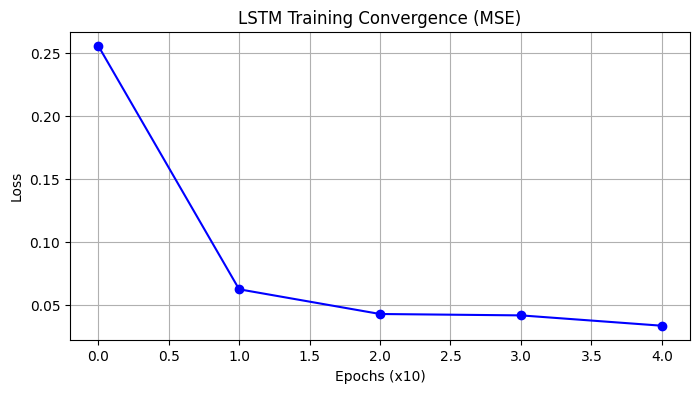

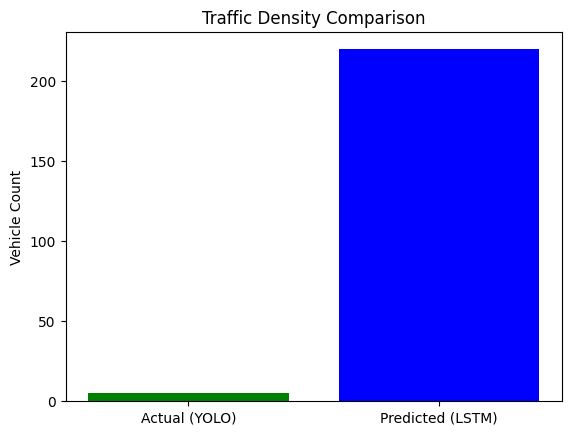

In [16]:
import matplotlib.pyplot as plt

# 1. Plot Training Loss
plt.figure(figsize=(8, 4))
plt.plot([0.2555, 0.0623, 0.0427, 0.0416, 0.0334], marker='o', color='b')
plt.title("LSTM Training Convergence (MSE)")
plt.xlabel("Epochs (x10)")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 2. Plot Predicted vs Actual for a sequence
# This helps visualize the 'Congestion Patterns' you mentioned
plt.bar(['Actual (YOLO)', 'Predicted (LSTM)'], [5, 219.72], color=['green', 'blue'])
plt.title("Traffic Density Comparison")
plt.ylabel("Vehicle Count")
plt.show()